<a href="https://www.kaggle.com/code/sonawanelalitsunil/water-pollution-disease-impact-analysis-ml-26?scriptVersionId=232305021" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/water-pollution-and-disease/water_pollution_disease.csv


## Title: Water Pollution & Disease Impact Analysis

## Description:
This study explores the relationship between water quality indicators and public health outcomes. Using global data on contaminants, treatment methods, and access to clean water, we analyze how water pollution correlates with disease prevalence and mortality rates.

## Import dataset

In [2]:
df  = pd.read_csv('/kaggle/input/water-pollution-and-disease/water_pollution_disease.csv')

In [3]:
df.head()

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414


In [4]:
df.tail()

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,18.52,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,16.98,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,7.99,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,19.86,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643
2999,Mexico,North,2013,Spring,0.98,7.69,2.55,7.42,19.78,1.04,...,3,79,3.62,72970,43.41,76.83,67.31,937,9.60,274


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentration (µg/L)                      3000 

In [6]:
df.describe()

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2012.012667,4.954390,7.255847,2.480023,6.492850,25.08025,10.047913,2488.477333,64.612333,249.776667,24.25100,49.270000,50.811900,50036.196667,50.029193,50.062480,60.371007,1591.849000,20.130917,505.390333
std,7.229287,2.860072,0.720464,1.419984,2.027966,14.50517,5.798238,1431.421553,20.308463,144.111543,14.33259,28.984165,28.465323,28598.750508,28.896676,22.779125,23.159678,817.502434,11.689244,283.275224
min,2000.000000,0.000000,6.000000,0.000000,3.000000,0.05000,0.000000,0.000000,30.010000,0.000000,0.00000,0.000000,2.060000,521.000000,0.190000,10.030000,20.010000,200.000000,0.060000,10.000000
25%,2006.000000,2.560000,6.630000,1.257500,4.710000,12.52500,5.120000,1268.000000,47.027500,124.000000,12.00000,24.000000,26.467500,25010.250000,24.982500,30.557500,40.440000,865.750000,9.840000,254.750000
50%,2012.000000,4.950000,7.280000,2.460000,6.490000,24.79000,10.065000,2469.000000,64.780000,248.000000,24.00000,49.000000,50.230000,49621.500000,50.390000,49.795000,60.580000,1572.000000,20.175000,513.000000
75%,2018.000000,7.400000,7.870000,3.660000,8.252500,37.91000,15.032500,3736.250000,82.302500,378.000000,37.00000,75.000000,76.260000,74778.250000,74.817500,69.727500,80.420000,2308.250000,30.672500,745.000000
max,2024.000000,10.000000,8.500000,4.990000,10.000000,49.99000,20.000000,4998.000000,99.990000,499.000000,49.00000,99.000000,99.990000,99948.000000,99.980000,89.980000,99.990000,2999.000000,39.990000,999.000000


In [7]:
df.isnull().sum()

Country                                            0
Region                                             0
Year                                               0
Water Source Type                                  0
Contaminant Level (ppm)                            0
pH Level                                           0
Turbidity (NTU)                                    0
Dissolved Oxygen (mg/L)                            0
Nitrate Level (mg/L)                               0
Lead Concentration (µg/L)                          0
Bacteria Count (CFU/mL)                            0
Water Treatment Method                           747
Access to Clean Water (% of Population)            0
Diarrheal Cases per 100,000 people                 0
Cholera Cases per 100,000 people                   0
Typhoid Cases per 100,000 people                   0
Infant Mortality Rate (per 1,000 live births)      0
GDP per Capita (USD)                               0
Healthcare Access Index (0-100)               

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes


Country                                           object
Region                                            object
Year                                               int64
Water Source Type                                 object
Contaminant Level (ppm)                          float64
pH Level                                         float64
Turbidity (NTU)                                  float64
Dissolved Oxygen (mg/L)                          float64
Nitrate Level (mg/L)                             float64
Lead Concentration (µg/L)                        float64
Bacteria Count (CFU/mL)                            int64
Water Treatment Method                            object
Access to Clean Water (% of Population)          float64
Diarrheal Cases per 100,000 people                 int64
Cholera Cases per 100,000 people                   int64
Typhoid Cases per 100,000 people                   int64
Infant Mortality Rate (per 1,000 live births)    float64
GDP per Capita (USD)           

In [10]:
df.shape

(3000, 24)

In [11]:
df.columns

Index(['Country', 'Region', 'Year', 'Water Source Type',
       'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Water Treatment Method', 'Access to Clean Water (% of Population)',
       'Diarrheal Cases per 100,000 people',
       'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)'],
      dtype='object')

## Data visualizations

Text(0.5, 1.0, 'Average Access to Clean Water by Country')

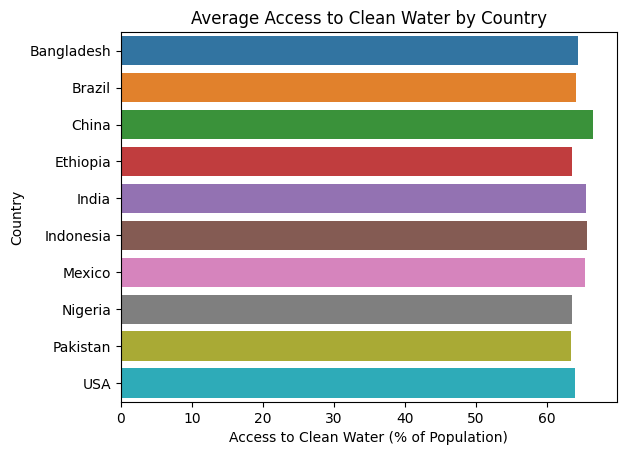

In [12]:
sns.barplot(data=df.groupby('Country')['Access to Clean Water (% of Population)'].mean().reset_index(),
            x='Access to Clean Water (% of Population)', y='Country')
plt.title("Average Access to Clean Water by Country")


Text(0.5, 1.0, 'Contaminant Level Over Time by Country')

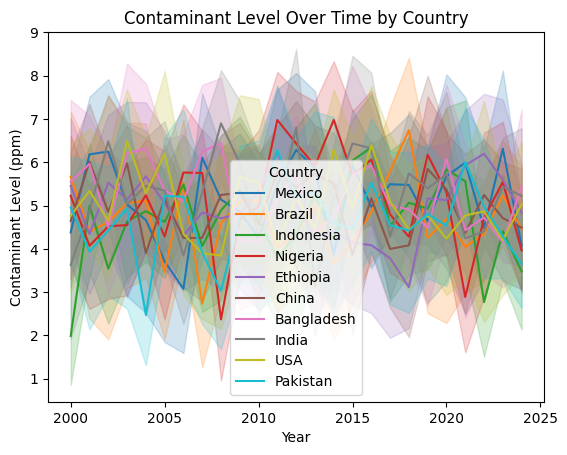

In [13]:
sns.lineplot(data=df, x='Year', y='Contaminant Level (ppm)', hue='Country')
plt.title('Contaminant Level Over Time by Country')


Text(0.5, 1.0, 'Waterborne Disease Cases Over Time')

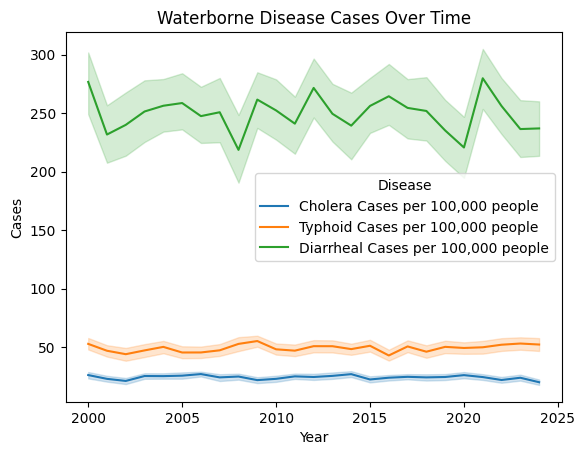

In [14]:
disease_cols = ['Cholera Cases per 100,000 people',
                'Typhoid Cases per 100,000 people',
                'Diarrheal Cases per 100,000 people']
df_melted = df.melt(id_vars='Year', value_vars=disease_cols,
                    var_name='Disease', value_name='Cases')
sns.lineplot(data=df_melted, x='Year', y='Cases', hue='Disease')
plt.title('Waterborne Disease Cases Over Time')


Text(0.5, 0.98, 'Distributions of Water Quality Indicators')

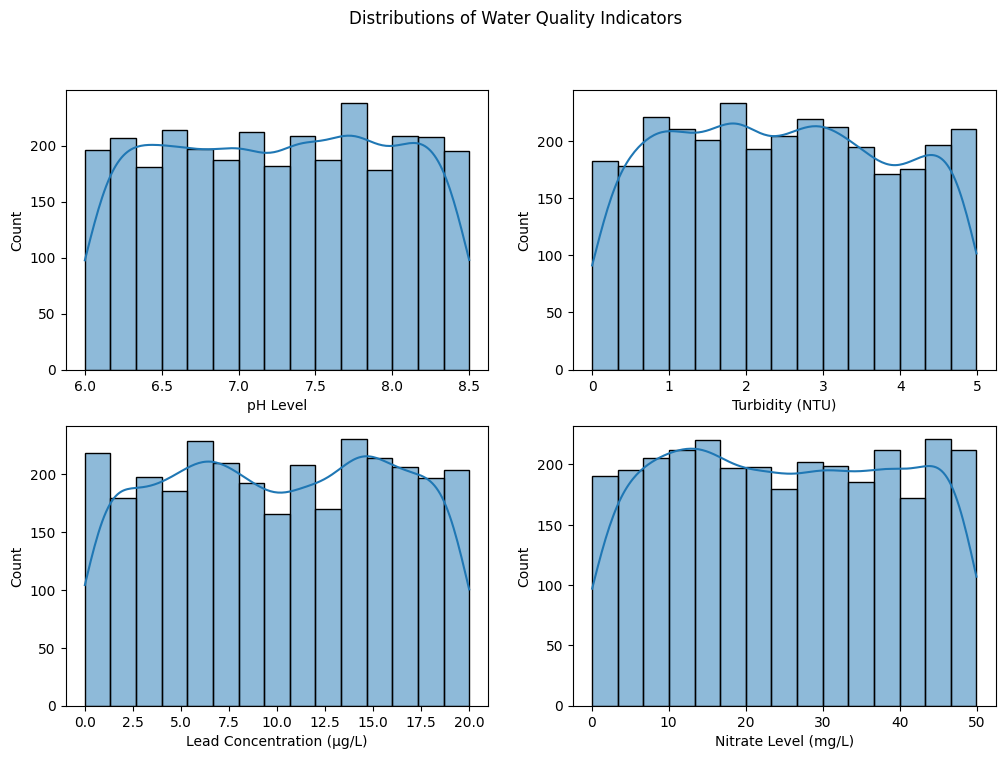

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['pH Level'], ax=axes[0, 0], kde=True)
sns.histplot(df['Turbidity (NTU)'], ax=axes[0, 1], kde=True)
sns.histplot(df['Lead Concentration (µg/L)'], ax=axes[1, 0], kde=True)
sns.histplot(df['Nitrate Level (mg/L)'], ax=axes[1, 1], kde=True)
fig.suptitle('Distributions of Water Quality Indicators')


Text(0.5, 1.0, 'Contaminant Level by Water Source')

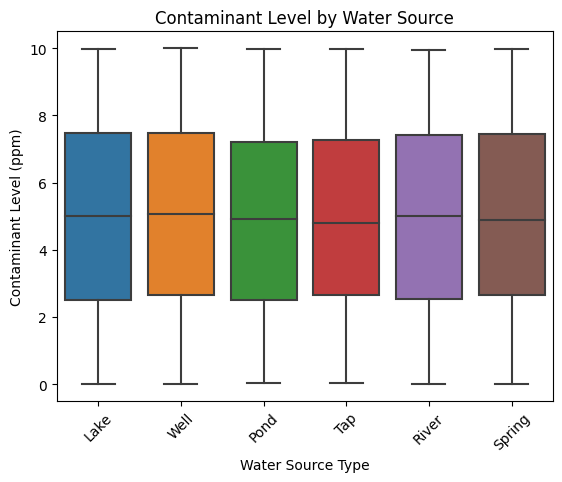

In [16]:
sns.boxplot(data=df, x='Water Source Type', y='Contaminant Level (ppm)')
plt.xticks(rotation=45)
plt.title('Contaminant Level by Water Source')


Text(0.5, 1.0, 'Temperature vs Bacteria Count')

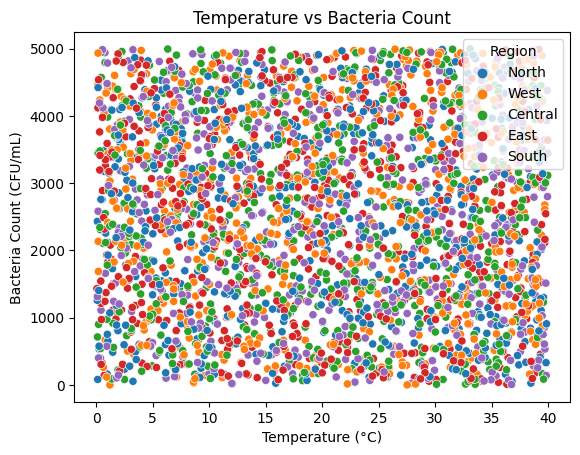

In [17]:
sns.scatterplot(data=df, x='Temperature (°C)', y='Bacteria Count (CFU/mL)', hue='Region')
plt.title('Temperature vs Bacteria Count')


Text(0.5, 1.0, 'Rainfall vs Clean Water Access')

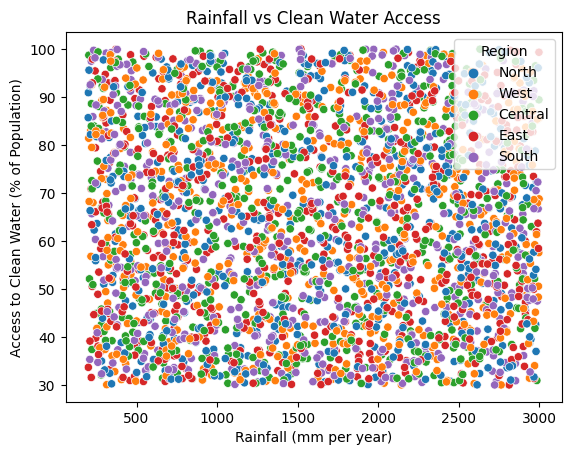

In [18]:
sns.scatterplot(data=df, x='Rainfall (mm per year)', y='Access to Clean Water (% of Population)', hue='Region')
plt.title('Rainfall vs Clean Water Access')


Text(0.5, 1.0, 'Clean Water Access vs Infant Mortality')

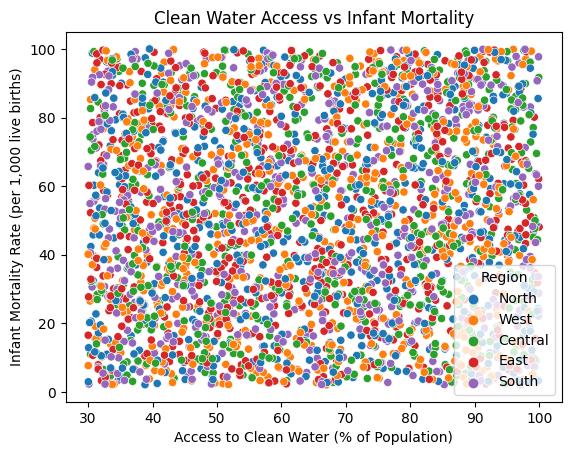

In [19]:
sns.scatterplot(data=df, x='Access to Clean Water (% of Population)', y='Infant Mortality Rate (per 1,000 live births)', hue='Region')
plt.title('Clean Water Access vs Infant Mortality')


Text(0.5, 1.0, 'GDP vs Healthcare Access')

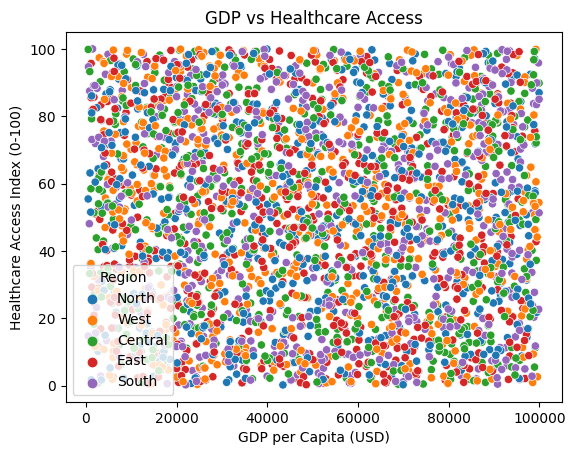

In [20]:
sns.scatterplot(data=df, x='GDP per Capita (USD)', y='Healthcare Access Index (0-100)', hue='Region')
plt.title('GDP vs Healthcare Access')


Text(0.5, 1.0, 'Urbanization vs Sanitation Coverage')

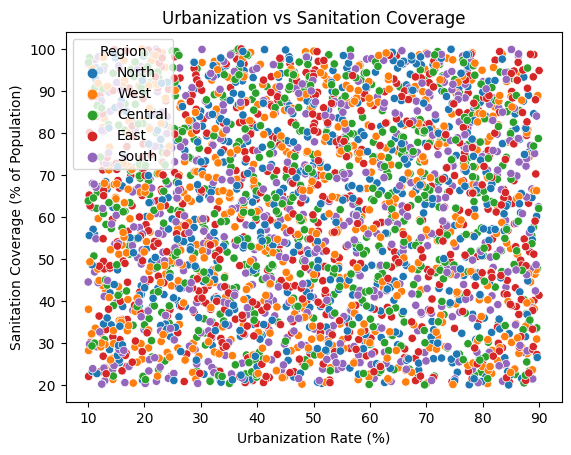

In [21]:
sns.scatterplot(data=df, x='Urbanization Rate (%)', y='Sanitation Coverage (% of Population)', hue='Region')
plt.title('Urbanization vs Sanitation Coverage')


Text(0.5, 1.0, 'Water Treatment Method Frequency')

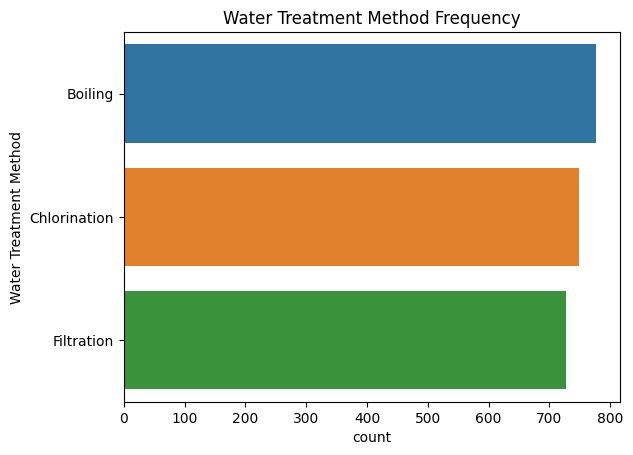

In [22]:
sns.countplot(data=df, y='Water Treatment Method', order=df['Water Treatment Method'].value_counts().index)
plt.title('Water Treatment Method Frequency')


Text(0.5, 1.0, 'Bacteria Count by Treatment Method')

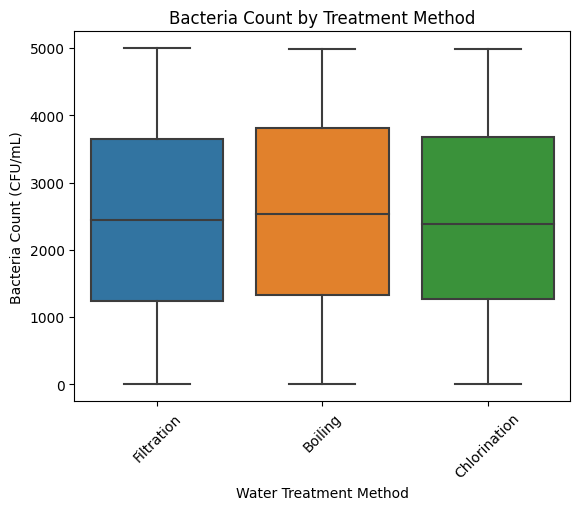

In [23]:
sns.boxplot(data=df, x='Water Treatment Method', y='Bacteria Count (CFU/mL)')
plt.xticks(rotation=45)
plt.title('Bacteria Count by Treatment Method')


## Predictive modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [25]:
# Choose a classification target (example: "Water Treatment Method")
target_col = 'Water Treatment Method'


In [26]:
# Split features and target
X = df.drop(columns=[target_col])
y = df[target_col]

In [27]:
# Encode categorical features
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


In [28]:
# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

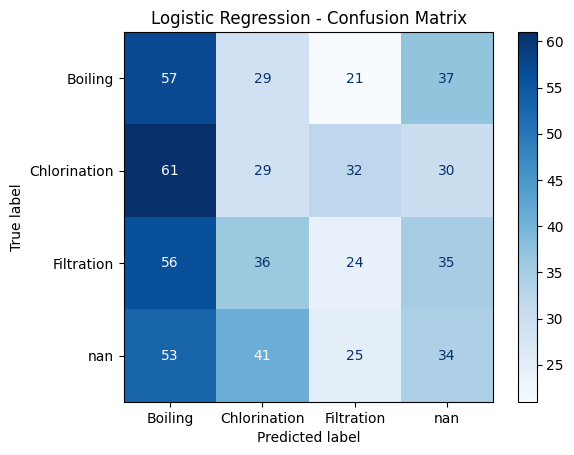

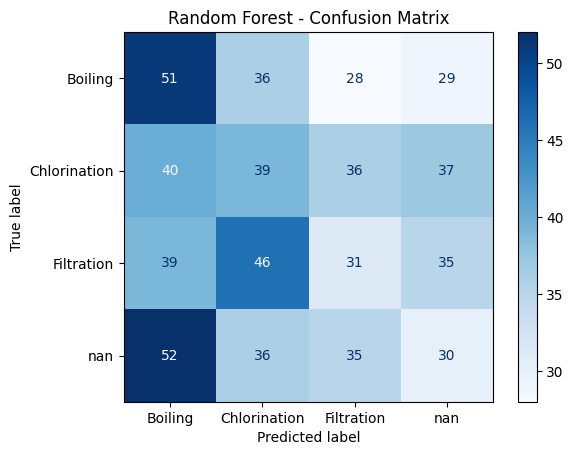

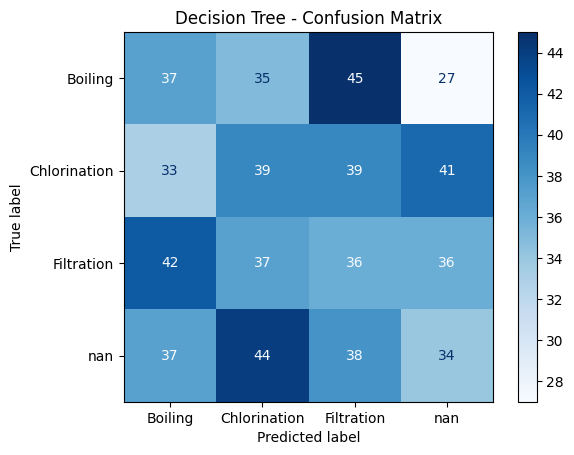

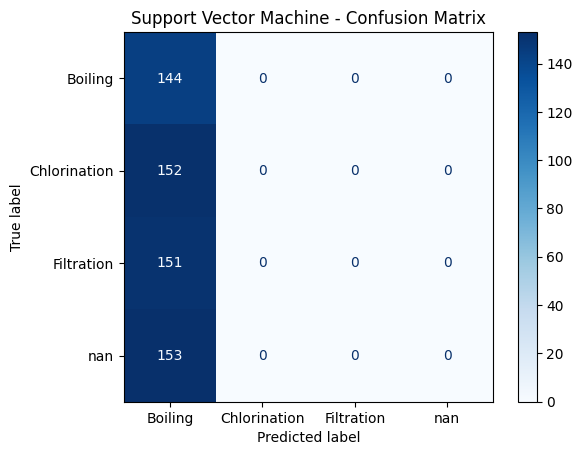

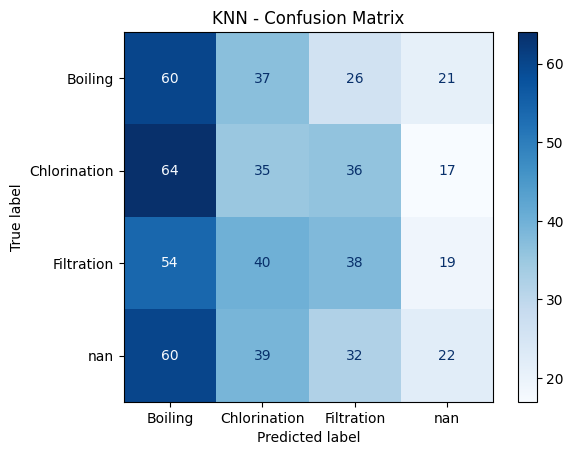

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    disp.plot(cmap='Blues')
    disp.ax_.set_title(f'{name} - Confusion Matrix')


In [31]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")


Logistic Regression Accuracy: 0.24
Random Forest Accuracy: 0.25
Decision Tree Accuracy: 0.24
Support Vector Machine Accuracy: 0.24
KNN Accuracy: 0.26


## Thank you!!!..pls upvote!!!